### GoogleNet

传统网络架构通常是串行的：一层卷积接一层池化，由于特征到底是用那种尺寸的卷积核抓取，因此提出了Inception模块（并行计算）

#### Inception模块（以3a 为例）
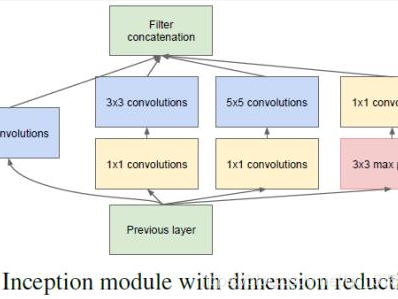

1. 1x1卷积层：维度压缩
- 降维：在3x3和5x5卷积核中，GoogleNet会加一个1x1卷积层，将通道数从512降为256，然后进行3x3和5x5卷积，这样在卷积核的计算量上speeds up
2. 全局平均池化：去掉臃肿的全连接
- AlexNet: 全连接层容易导致过拟合
- GoogleNet: 对最后一层特征图进行全局平均池化
- 好处：参数量剧减，同时可以更好保留局部空间信息
  

3. 辅助分类器
- 防止梯度消失
- 训练时计算额外的损失函数，直接把梯度传回中间层，确保深层网络的底部也可以学到特征

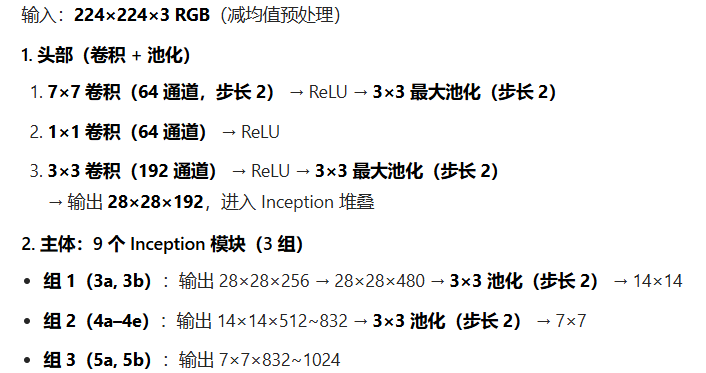

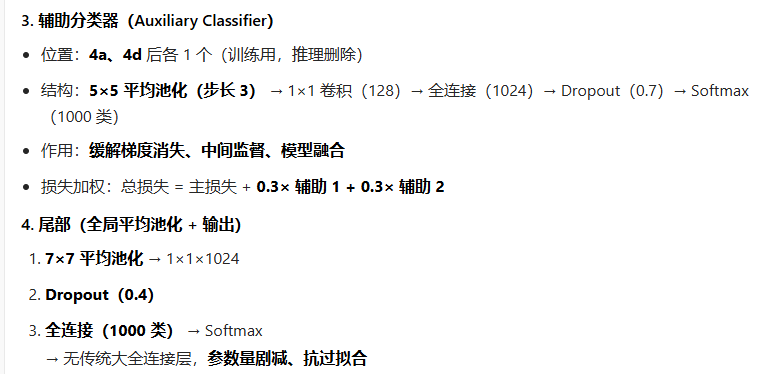

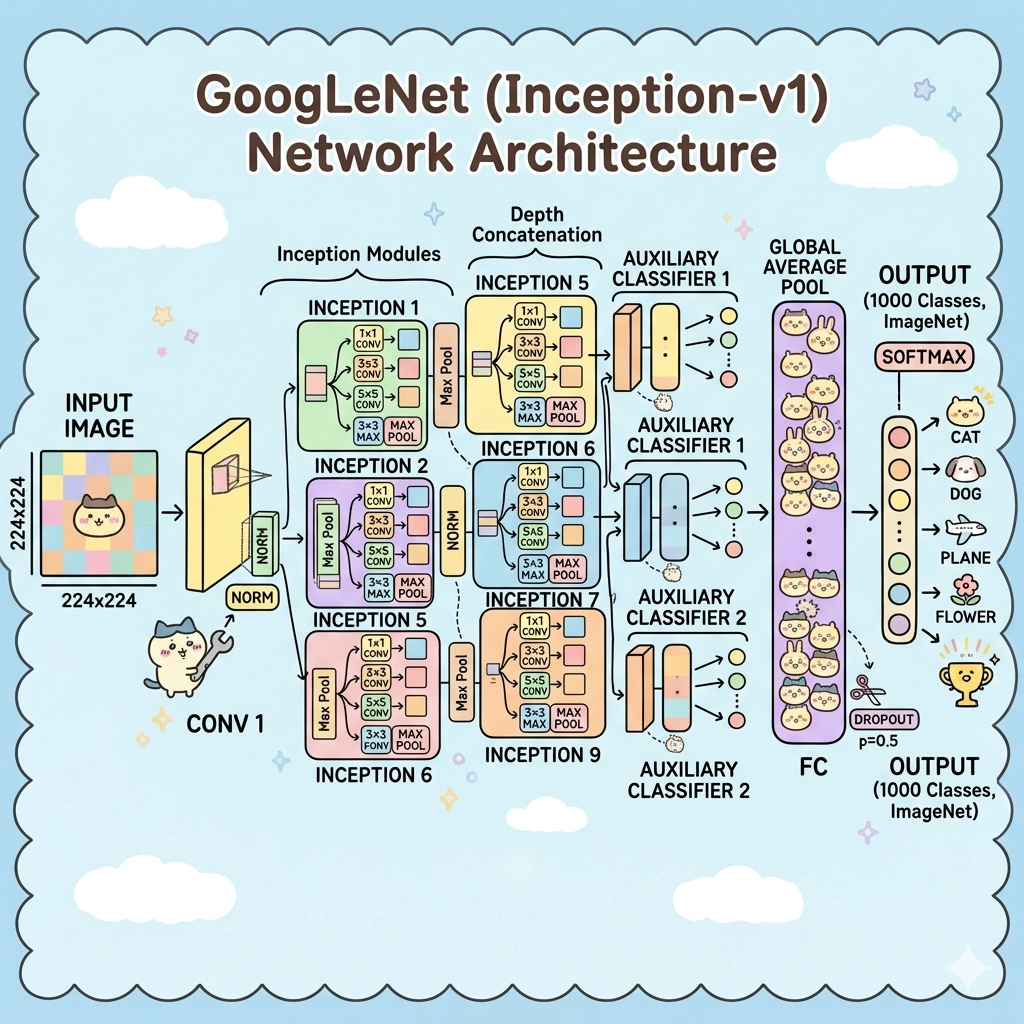

In [1]:
import torch
from torch import nn
from torchsummary import summary

In [2]:
class Inception(nn.Module):
    def __init__(self, in_channels, c1, c2, c3, c4):
        super(Inception, self).__init__()
        self.ReLU = nn.ReLU()

        # 路线1，单1×1卷积层.提取局部细粒度特征
        self.p1_1 = nn.Conv2d(in_channels=in_channels, out_channels=c1, kernel_size=1)

        # 路线2，1×1卷积层, 3×3的卷积，中等感受野特征
        self.p2_1 = nn.Conv2d(in_channels=in_channels, out_channels=c2[0], kernel_size=1)
        self.p2_2 = nn.Conv2d(in_channels=c2[0], out_channels=c2[1], kernel_size=3, padding=1)

        # 路线3，1×1卷积层, 5×5的卷积，大感受野特征
        self.p3_1 = nn.Conv2d(in_channels=in_channels, out_channels=c3[0], kernel_size=1)
        self.p3_2 = nn.Conv2d(in_channels=c3[0], out_channels=c3[1], kernel_size=5, padding=2)

        # 路线4，3×3的最大池化, 1×1的卷积，池化特征
        self.p4_1 = nn.MaxPool2d(kernel_size=3, padding=1, stride=1)
        self.p4_2 = nn.Conv2d(in_channels=in_channels, out_channels=c4, kernel_size=1)



    def forward(self, x):
        p1 = self.ReLU(self.p1_1(x))
        p2 = self.ReLU(self.p2_2(self.ReLU(self.p2_1(x))))
        p3 = self.ReLU(self.p3_2(self.ReLU(self.p3_1(x))))
        p4 = self.ReLU(self.p4_2(self.p4_1(x)))
        return torch.cat((p1, p2, p3, p4), dim=1)

In [3]:
class GoogLeNet(nn.Module):
    def __init__(self, Inception):
        super(GoogLeNet, self).__init__()
        self.b1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=64, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

        self.b2 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=192, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

        self.b3 = nn.Sequential(
            Inception(192, 64, (96, 128), (16, 32), 32),
            Inception(256, 128, (128, 192), (32, 96), 64),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

        self.b4 = nn.Sequential(
            Inception(480, 192, (96, 208), (16, 48), 64),
            Inception(512, 160, (112, 224), (24, 64), 64),
            Inception(512, 128, (128, 256), (24, 64), 64),
            Inception(512, 112, (128, 288), (32, 64), 64),
            Inception(528, 256, (160, 320), (32, 128), 128),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

        self.b5 = nn.Sequential(
            Inception(832, 256, (160, 320), (32, 128), 128),
            Inception(832, 384, (192, 384), (48, 128), 128),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(1024, 10))

        for m in self.modules():
            # 卷积层权重初始化
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            #全连接层权重初始化
                elif isinstance(m, nn.Linear):
                    nn.init.normal_(m.weight, 0, 0.01)
                    if m.bias is not None:
                        nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.b1(x)
        x = self.b2(x)
        x = self.b3(x)
        x = self.b4(x)
        x = self.b5(x)
        return x

In [4]:
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = GoogLeNet(Inception).to(device)
    print(summary(model, (1, 224, 224)))
    

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           3,200
              ReLU-2         [-1, 64, 112, 112]               0
         MaxPool2d-3           [-1, 64, 56, 56]               0
            Conv2d-4           [-1, 64, 56, 56]           4,160
              ReLU-5           [-1, 64, 56, 56]               0
            Conv2d-6          [-1, 192, 56, 56]         110,784
              ReLU-7          [-1, 192, 56, 56]               0
         MaxPool2d-8          [-1, 192, 28, 28]               0
            Conv2d-9           [-1, 64, 28, 28]          12,352
             ReLU-10           [-1, 64, 28, 28]               0
           Conv2d-11           [-1, 96, 28, 28]          18,528
             ReLU-12           [-1, 96, 28, 28]               0
           Conv2d-13          [-1, 128, 28, 28]         110,720
             ReLU-14          [-1, 128,